<a href="https://colab.research.google.com/github/quasarx-snips/sih/blob/main/neural_models/M1_Models/maths1_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import entropy, skew, kurtosis
from scipy.fft import dctn
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, learning_curve
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report
from sklearn.exceptions import UndefinedMetricWarning

from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/OrbitalTrust_Data'
REAL_DIR = os.path.join(DATASET_PATH, 'real')
FAKE_DIR = os.path.join(DATASET_PATH, 'fake')
print(f"Real folder exists: {os.path.exists(REAL_DIR)}")
print(f"Fake folder exists: {os.path.exists(FAKE_DIR)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Real folder exists: True
Fake folder exists: True


In [43]:
def _safe_corr(a, b):
    """Pearson correlation that degrades gracefully on constant channels."""
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 1.0
    return float(np.corrcoef(a, b)[0, 1])


def _benford_deviation(ac_coeffs):
    """
    Chi-square deviation of DCT AC-coefficient leading digits from Benford's
    Law. Natural-sensor imagery tends to follow Benford's Law closely;
    GAN/diffusion-generated imagery frequently deviates due to unnatural
    coefficient statistics introduced by upsampling/synthesis. Classic
    signal in JPEG/image forensics literature.
    """
    vals = np.abs(ac_coeffs[ac_coeffs != 0])
    if len(vals) < 10:
        return 0.0
    leading = np.floor(vals / (10 ** np.floor(np.log10(vals)))).astype(int)
    leading = leading[(leading >= 1) & (leading <= 9)]
    if len(leading) < 10:
        return 0.0
    observed = np.array([np.sum(leading == d) for d in range(1, 10)], dtype=float)
    observed = observed / observed.sum()
    benford = np.array([np.log10(1 + 1 / d) for d in range(1, 10)])
    return float(np.sum((observed - benford) ** 2 / (benford + 1e-12)))


def extract_math_features_from_array(img, patch_size=32):
    """
    Core feature extractor — operates on an in-memory BGR image array so it
    can be reused for both disk-loaded images and augmented in-memory views.

    Extracts a 21-dimensional mathematical/statistical forensic vector:
      - Multi-patch Shannon Entropy (mean, std, skew, kurtosis)
      - Multi-ring FFT Power Spectral Densities (Low/Mid/High)
      - Multi-angle (0/45/90/135) GLCM texture, averaged for robustness
      - Spatial Gradient (Sobel) & Laplacian energy
      - Block-DCT AC energy + Benford's-Law leading-digit deviation
      - Sensor noise-residual statistics (std + entropy)
      - Cross-channel colour correlation (R-G, G-B)
      - Local Binary Pattern micro-texture entropy
    """
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # 1. Patch-based Shannon entropy statistics (unchanged from v1)
    patch_entropies = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = gray[i:i + patch_size, j:j + patch_size]
            hist, _ = np.histogram(patch.ravel(), bins=32, range=(0, 256))
            prob = hist / (hist.sum() + 1e-12)
            patch_entropies.append(entropy(prob + 1e-12, base=2))
    patch_entropies = np.array(patch_entropies)
    ent_mean = np.mean(patch_entropies) if len(patch_entropies) else 0.0
    ent_std = np.std(patch_entropies) if len(patch_entropies) else 0.0
    ent_skew = float(skew(patch_entropies)) if len(patch_entropies) else 0.0
    ent_kurt = float(kurtosis(patch_entropies)) if len(patch_entropies) else 0.0

    # 2. FFT concentric-ring power spectral density (unchanged; already
    #    rotation-invariant by construction, since it bins by radial distance)
    f_shift = np.fft.fftshift(np.fft.fft2(gray))
    mag_spec = np.abs(f_shift) ** 2
    total_power = np.sum(mag_spec) + 1e-12
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    max_r = min(h, w) // 2
    r_low, r_mid = max_r * 0.1, max_r * 0.4
    low_power = np.sum(mag_spec[dist <= r_low]) / total_power
    mid_power = np.sum(mag_spec[(dist > r_low) & (dist <= r_mid)]) / total_power
    high_power = np.sum(mag_spec[dist > r_mid]) / total_power

    # 3. Multi-angle GLCM (0, 45, 90, 135) averaged -> less noisy than v1's
    #    single angle=0, and no longer orientation-fragile
    gray_q = (gray // 16).astype(np.uint8)
    glcm = graycomatrix(gray_q, distances=[1], angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
                         levels=16, symmetric=True, normed=True)
    glcm_contrast = graycoprops(glcm, 'contrast').mean()
    glcm_dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    glcm_homogeneity = graycoprops(glcm, 'homogeneity').mean()
    glcm_energy = graycoprops(glcm, 'energy').mean()
    glcm_correlation = graycoprops(glcm, 'correlation').mean()

    # 4. Spatial gradient / Laplacian energy (unchanged)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_energy = np.mean(sobelx ** 2 + sobely ** 2)

    # 5. Block-DCT forensic features: AC energy + Benford deviation
    gray_f = gray.astype(np.float32)
    bs = 8
    ac_energies, all_ac = [], []
    for i in range(0, h - bs + 1, bs):
        for j in range(0, w - bs + 1, bs):
            block = gray_f[i:i + bs, j:j + bs]
            d = dctn(block, norm='ortho')
            ac = d.flatten()[1:]  # drop DC term
            ac_energies.append(np.sum(ac ** 2))
            all_ac.append(ac)
    dct_ac_energy = float(np.mean(ac_energies)) if ac_energies else 0.0
    all_ac = np.concatenate(all_ac) if all_ac else np.array([])
    benford_dev = _benford_deviation(all_ac)

    # 6. Sensor noise-residual statistics — real sensor noise has a natural
    #    high-frequency floor that GAN/diffusion imagery often under- or
    #    over-represents
    denoised = cv2.medianBlur(gray, 3)
    residual = gray.astype(np.int16) - denoised.astype(np.int16)
    noise_std = float(np.std(residual))
    hist_r, _ = np.histogram(residual.ravel(), bins=64, range=(-32, 32))
    prob_r = hist_r / (hist_r.sum() + 1e-12)
    noise_entropy = float(entropy(prob_r + 1e-12, base=2))

    # 7. Cross-channel colour correlation
    b, g, r = cv2.split(img.astype(np.float32))
    channel_corr_rg = _safe_corr(r.ravel(), g.ravel())
    channel_corr_gb = _safe_corr(g.ravel(), b.ravel())

    # 8. Local Binary Pattern micro-texture entropy
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist_l, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
    prob_l = hist_l / (hist_l.sum() + 1e-12)
    lbp_entropy = float(entropy(prob_l + 1e-12, base=2))

    return {
        'ent_mean': ent_mean, 'ent_std': ent_std, 'ent_skew': ent_skew, 'ent_kurt': ent_kurt,
        'fft_low_power': low_power, 'fft_mid_power': mid_power, 'fft_high_power': high_power,
        'glcm_contrast': glcm_contrast, 'glcm_dissimilarity': glcm_dissimilarity,
        'glcm_homogeneity': glcm_homogeneity, 'glcm_energy': glcm_energy,
        'glcm_correlation': glcm_correlation,
        'laplacian_var': laplacian_var, 'sobel_energy': sobel_energy,
        'dct_ac_energy': dct_ac_energy, 'benford_dev': benford_dev,
        'noise_std': noise_std, 'noise_entropy': noise_entropy,
        'channel_corr_rg': channel_corr_rg, 'channel_corr_gb': channel_corr_gb,
        'lbp_entropy': lbp_entropy,
    }


def extract_math_features(img_path, patch_size=32):
    """Path-based wrapper, kept for drop-in compatibility with v1 call sites."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    return extract_math_features_from_array(img, patch_size=patch_size)


In [49]:
def _dihedral_transforms(img):
    flips = [img, cv2.flip(img, 1)]
    out = []
    for base in flips:
        out.append(base)
        out.append(cv2.rotate(base, cv2.ROTATE_90_CLOCKWISE))
        out.append(cv2.rotate(base, cv2.ROTATE_180))
        out.append(cv2.rotate(base, cv2.ROTATE_90_COUNTERCLOCKWISE))
    return out  # 8 views total


def build_math_dataset(real_path, fake_path, max_samples=1500):
    records = []
    exts = ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.webp')
    real_files, fake_files = [], []
    for ext in exts:
        real_files.extend(glob.glob(os.path.join(real_path, ext)))
        fake_files.extend(glob.glob(os.path.join(fake_path, ext)))
    print(f"Discovered: {len(real_files)} Real images, {len(fake_files)} Fake images.")

    for label, files in [(0, real_files[:max_samples]), (1, fake_files[:max_samples])]:
        for f in files:
            img = cv2.imread(f)
            if img is None:
                continue
            source_id = os.path.basename(f)
            for view_idx, view in enumerate(_dihedral_transforms(img)):
                feats = extract_math_features_from_array(view)
                if feats:
                    feats['label'] = label
                    feats['source_id'] = source_id
                    feats['view'] = view_idx
                    records.append(feats)
    return pd.DataFrame(records)


df = build_math_dataset(REAL_DIR, FAKE_DIR, max_samples=1500)

# IMPORTANT: build_math_dataset appends all real rows first, then all fake
# rows, so unshuffled df/X/y/groups are class-ordered (real block, fake
# block). StratifiedGroupKFold's train indices come back in ascending
# order, and learning_curve's small train_sizes fractions just slice the
# first N of that array - on class-ordered data that slice can land almost
# entirely on one class, crashing LogisticRegression ("only one class").
# Shuffling once here fixes it for every downstream step.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nExtracted 21-dimensional math vectors for {len(df)} rows "
      f"({df['source_id'].nunique()} unique source images x 8 dihedral views).")
df.head()



Discovered: 50 Real images, 50 Fake images.

Extracted 21-dimensional math vectors for 800 rows (50 unique source images x 8 dihedral views).


,ent_mean,ent_std,ent_skew,ent_kurt,fft_low_power,fft_mid_power,fft_high_power,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,...,dct_ac_energy,benford_dev,noise_std,noise_entropy,channel_corr_rg,channel_corr_gb,lbp_entropy,label,source_id,view
0,2.394464,0.973780,0.194877,-0.870082,0.986949,0.008636,0.004415,0.876052,0.411651,0.831306,...,15117.199219,0.019626,6.352850,3.318167,0.980849,0.989134,3.186650,1,000000016.jpg,0
1,3.841768,0.362581,-0.009482,-0.428918,0.902861,0.060194,0.036945,3.030213,1.080748,0.608887,...,50778.039062,0.028971,13.906489,4.903785,0.967716,0.947703,3.277697,1,000000014.jpg,3
2,2.872271,0.557856,-0.060138,-0.373577,0.956388,0.026673,0.016939,0.934953,0.606049,0.727952,...,13711.207031,0.035469,7.170700,4.380557,0.995786,0.990045,3.252566,0,000000028.jpg,7
3,3.364942,0.526607,-0.967584,1.186302,0.961513,0.030505,0.007981,1.120138,0.651239,0.718493,...,25047.650391,0.031139,6.716061,4.149410,0.952851,0.981338,3.192224,1,000000029.jpg,5
4,4.842247,0.053812,-0.427551,-0.590756,0.743708,0.072750,0.183542,24.699411,3.897082,0.235165,...,250986.531250,0.012560,49.470948,5.197028,0.998420,0.998792,3.222340,0,000000042.jpg,2


In [50]:
feature_cols = [c for c in df.columns if c not in ['label', 'source_id', 'view']]
X = df[feature_cols].values
y = df['label'].values
groups = df['source_id'].values

# --- Step A: which features actually separate the classes? ---------------
# f_classif gives an ANOVA F-score per feature (computed once here just for
# diagnostics/printing — the pipelines below redo this properly inside CV).
f_scores, _ = f_classif(X, y)
feat_rank = sorted(zip(feature_cols, f_scores), key=lambda t: t[1], reverse=True)
print("Feature separation ranking (higher F-score = better real/fake split):")
for name, score in feat_rank:
    print(f"  {name:<20s} F={score:8.2f}")
top_features = [name for name, _ in feat_rank[:6]]
top_idx = [feature_cols.index(n) for n in top_features]
print(f"\nTop 6 features: {top_features}")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(pipeline, X_in, label):
    """Out-of-fold accuracy/AUC for a given pipeline + feature matrix."""
    probs = cross_val_predict(pipeline, X_in, y, cv=cv, groups=groups,
                               method='predict_proba', n_jobs=-1)[:, 1]
    fpr, tpr, thr = roc_curve(y, probs)
    j = tpr - fpr
    idx = np.argmax(j)
    thresh = thr[idx]
    preds = (probs >= thresh).astype(int)
    acc = accuracy_score(y, preds)
    a = auc(fpr, tpr)
    print(f"{label:<32s} AUC={a:.4f}  Accuracy={acc*100:6.2f}%  "
          f"TPR={tpr[idx]*100:5.1f}%  FPR={fpr[idx]*100:5.1f}%")
    return probs, thresh, acc, a


# --- Step B: candidate models, cheapest/simplest first --------------------
candidates = {
    "A) Plain LR, all 21 features": (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced'))]),
        X),
    "B) Plain LR, top-6 features only": (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced'))]),
        X[:, top_idx]),
    "C) LR + SelectKBest(12), no ensemble": (
        Pipeline([('scaler', StandardScaler()),
                  ('select', SelectKBest(score_func=f_classif, k=12)),
                  ('clf', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced'))]),
        X),
    "D) Full ensemble (v2, previous cell)": (
        Pipeline([('scaler', StandardScaler()),
                  ('select', SelectKBest(score_func=f_classif, k=12)),
                  ('clf', VotingClassifier(estimators=[
                      ('lr', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced')),
                      ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced')),
                      ('hgb', HistGradientBoostingClassifier(max_iter=60, max_depth=3, learning_rate=0.05,
                                                              l2_regularization=1.0, min_samples_leaf=10,
                                                              random_state=42)),
                  ], voting='soft'))]),
        X),
}

print("\n" + "=" * 78)
print(" MODEL COMPARISON — out-of-fold, group-aware (no leakage) ")
print("=" * 78)
results = {}
for label, (pipe, X_in) in candidates.items():
    results[label] = evaluate(pipe, X_in, label)

# Pick whichever candidate scored highest OOF accuracy as the deployed model.
best_label = max(results, key=lambda k: results[k][2])
best_probs, optimal_threshold, oof_accuracy, math_auc = results[best_label]
oof_preds = (best_probs >= optimal_threshold).astype(int)
pipeline, X_final = candidates[best_label]

print("\n" + "=" * 55)
print(f" SELECTED MODEL: {best_label}")
print("=" * 55)
print(f"• Optimal Anomaly Threshold  : {optimal_threshold:.4f}")
print(f"• ROC-AUC (out-of-fold)      : {math_auc:.4f}")
print(f"• Accuracy (out-of-fold)     : {oof_accuracy * 100:.2f}%")
print("=" * 55)
print(classification_report(y, oof_preds, target_names=['Real', 'Fake']))

# Final deployed model: refit the SELECTED pipeline on ALL data.
# NOTE: if the selected model is candidate B, feature_cols downstream (Cell 6)
# must be restricted to top_features — see the assignment right below.
if best_label == "B) Plain LR, top-6 features only":
    feature_cols = top_features
math_engine = pipeline.fit(X_final, y)



Feature separation ranking (higher F-score = better real/fake split):
  benford_dev          F=   48.19
  noise_std            F=   46.31
  fft_high_power       F=   36.03
  glcm_correlation     F=   34.37
  laplacian_var        F=   31.76
  ent_kurt             F=   26.01
  glcm_dissimilarity   F=   20.86
  glcm_contrast        F=   20.27
  glcm_homogeneity     F=   17.49
  ent_skew             F=   16.58
  noise_entropy        F=   15.94
  fft_mid_power        F=    9.12
  glcm_energy          F=    6.03
  sobel_energy         F=    4.86
  dct_ac_energy        F=    3.44
  fft_low_power        F=    2.95
  channel_corr_gb      F=    2.35
  channel_corr_rg      F=    2.13
  ent_mean             F=    1.40
  ent_std              F=    0.34
  lbp_entropy          F=    0.27

Top 6 features: ['benford_dev', 'noise_std', 'fft_high_power', 'glcm_correlation', 'laplacian_var', 'ent_kurt']

 MODEL COMPARISON — out-of-fold, group-aware (no leakage) 
A) Plain LR, all 21 features     AUC=0.7763

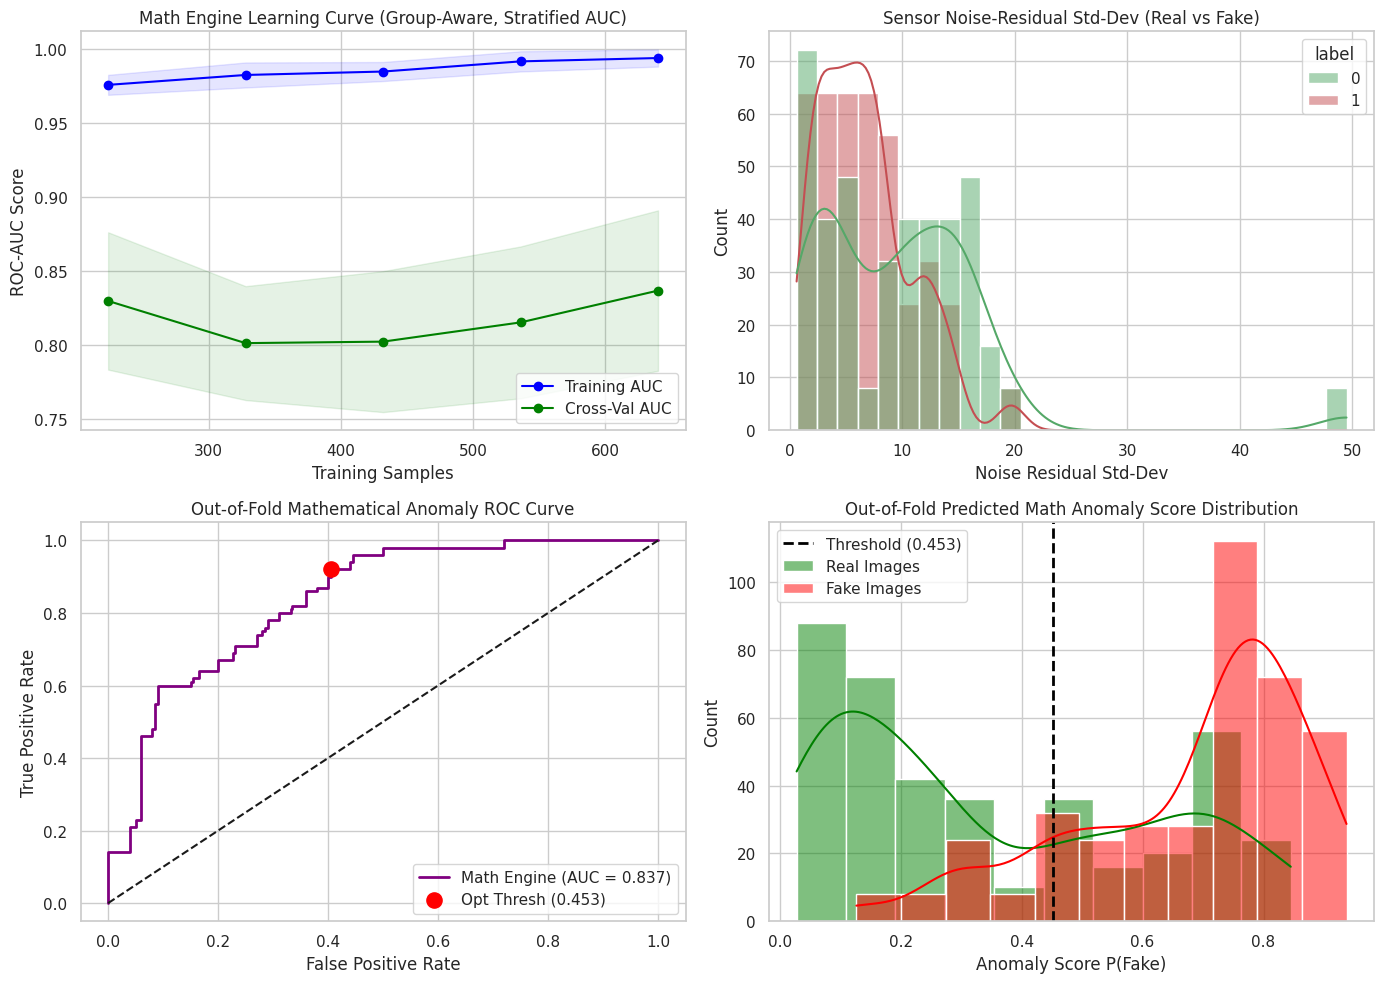

In [51]:
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# 1. Group-aware learning curve (train vs cross-val AUC as data grows)
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, groups=groups, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.35, 1.0, 5), n_jobs=-1, random_state=42
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)
axes[0, 0].plot(train_sizes, train_mean, 'o-', color='blue', label='Training AUC')
axes[0, 0].plot(train_sizes, test_mean, 'o-', color='green', label='Cross-Val AUC')
axes[0, 0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
axes[0, 0].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
axes[0, 0].set_title('Math Engine Learning Curve (Group-Aware, Stratified AUC)')
axes[0, 0].set_xlabel('Training Samples')
axes[0, 0].set_ylabel('ROC-AUC Score')
axes[0, 0].legend(loc='lower right')

# 2. New forensic signal: sensor noise-residual std-dev by class
sns.histplot(data=df, x='noise_std', hue='label', kde=True, ax=axes[0, 1],
             palette=['g', 'r'], alpha=0.5)
axes[0, 1].set_title('Sensor Noise-Residual Std-Dev (Real vs Fake)')
axes[0, 1].set_xlabel('Noise Residual Std-Dev')

# 3. Out-of-fold ROC curve & optimal threshold point
axes[1, 0].plot(fpr, tpr, color='purple', linewidth=2, label=f'Math Engine (AUC = {math_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=120, zorder=5,
                    label=f'Opt Thresh ({optimal_threshold:.3f})')
axes[1, 0].set_title('Out-of-Fold Mathematical Anomaly ROC Curve')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend()

# 4. Out-of-fold anomaly-score distribution & cutoff
sns.histplot(oof_probs[y == 0], color='green', kde=True, ax=axes[1, 1], label='Real Images', alpha=0.5)
sns.histplot(oof_probs[y == 1], color='red', kde=True, ax=axes[1, 1], label='Fake Images', alpha=0.5)
axes[1, 1].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2,
                    label=f'Threshold ({optimal_threshold:.3f})')
axes[1, 1].set_title('Out-of-Fold Predicted Math Anomaly Score Distribution')
axes[1, 1].set_xlabel('Anomaly Score P(Fake)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [52]:
def predict_satellite_image(img_path, threshold=optimal_threshold):
    """
    Extracts the 21-D mathematical forensic vector for all 8 dihedral views
    of the input image, averages the fake-probability across views (test-
    time augmentation — the same trick used in training, applied once at
    inference), and returns a verdict.
    Returns: Tuple (verdict: str, fake_prob: float)
    """
    if not os.path.exists(img_path):
        print(f"Error: File not found at path -> '{img_path}'")
        return "ERROR: FILE_NOT_FOUND", 0.0

    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: OpenCV failed to read image -> '{img_path}'")
        return "ERROR: UNREADABLE_IMAGE", 0.0

    view_feats = []
    for view in _dihedral_transforms(img):
        feats = extract_math_features_from_array(view)
        if feats:
            view_feats.append(feats)
    if not view_feats:
        return "ERROR: FEATURE_EXTRACTION_FAILED", 0.0

    feat_df = pd.DataFrame(view_feats)[feature_cols]
    fake_probs = math_engine.predict_proba(feat_df.values)[:, 1]
    fake_prob = float(np.mean(fake_probs))
    verdict = "FAKE / SYNTHETIC" if fake_prob >= threshold else "REAL / AUTHENTIC"

    print("=" * 45)
    print(f" ORBITALTRUST FORENSIC VERDICT: {verdict}")
    print("=" * 45)
    print(f"• Anomaly Score P(Fake) [8-view avg] : {fake_prob:.4f}")
    print(f"• Optimal Cutoff Thresh              : {threshold:.4f}")
    print(f"• View-wise Score Std-Dev            : {np.std(fake_probs):.4f}")
    print("=" * 45)
    return verdict, fake_prob

# Example:
verdict, score = predict_satellite_image('/content/000000047.jpg')

 ORBITALTRUST FORENSIC VERDICT: REAL / AUTHENTIC
• Anomaly Score P(Fake) [8-view avg] : 0.1773
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0004


In [55]:
predict_satellite_image('/content/000000000.jpg')

 ORBITALTRUST FORENSIC VERDICT: FAKE / SYNTHETIC
• Anomaly Score P(Fake) [8-view avg] : 0.8373
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0006


('FAKE / SYNTHETIC', 0.8373473488118096)

In [56]:
predict_satellite_image('/content/000000006.jpg')

 ORBITALTRUST FORENSIC VERDICT: FAKE / SYNTHETIC
• Anomaly Score P(Fake) [8-view avg] : 0.8637
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0000


('FAKE / SYNTHETIC', 0.8636980577070585)

In [57]:
predict_satellite_image('/content/000000042.jpg')

 ORBITALTRUST FORENSIC VERDICT: FAKE / SYNTHETIC
• Anomaly Score P(Fake) [8-view avg] : 0.7920
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0000


('FAKE / SYNTHETIC', 0.7920053115591366)

In [58]:
predict_satellite_image('/content/000000047.jpg')

 ORBITALTRUST FORENSIC VERDICT: REAL / AUTHENTIC
• Anomaly Score P(Fake) [8-view avg] : 0.1773
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0004


('REAL / AUTHENTIC', 0.17726574029923992)

In [60]:
predict_satellite_image('/content/000000001.jpg')

 ORBITALTRUST FORENSIC VERDICT: FAKE / SYNTHETIC
• Anomaly Score P(Fake) [8-view avg] : 0.5979
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0105


('FAKE / SYNTHETIC', 0.5978621773109392)

In [61]:
predict_satellite_image('/content/000000002.jpg')

 ORBITALTRUST FORENSIC VERDICT: REAL / AUTHENTIC
• Anomaly Score P(Fake) [8-view avg] : 0.3603
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0001


('REAL / AUTHENTIC', 0.36031590191466867)

In [62]:
predict_satellite_image('/content/000000003.jpg')

 ORBITALTRUST FORENSIC VERDICT: REAL / AUTHENTIC
• Anomaly Score P(Fake) [8-view avg] : 0.0584
• Optimal Cutoff Thresh              : 0.4526
• View-wise Score Std-Dev            : 0.0037


('REAL / AUTHENTIC', 0.058417316426247395)